In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
gdp = pd.read_csv("C:/Users/deepa/OneDrive/Desktop/MACROECONOMIC RECESSION PREDICTION/GDP.csv")

In [6]:
cpi = pd.read_csv("C:/Users/deepa/OneDrive/Desktop/MACROECONOMIC RECESSION PREDICTION/CPIAUCSL.csv")


In [7]:
unemployment = pd.read_csv("C:/Users/deepa/OneDrive/Desktop/MACROECONOMIC RECESSION PREDICTION/UNRATE.csv")

In [8]:
interest_rate = pd.read_csv("C:/Users/deepa/OneDrive/Desktop/MACROECONOMIC RECESSION PREDICTION/FEDFUNDS.csv")

In [9]:
recession_periods = pd.read_csv("C:/Users/deepa/OneDrive/Desktop/MACROECONOMIC RECESSION PREDICTION/USRECQ.csv")

In [11]:
print(df.columns)

NameError: name 'df' is not defined

In [12]:
df.columns = df.columns.str.strip()


NameError: name 'df' is not defined

In [13]:
df.rename(columns={df.columns[0]: "DATE"}, inplace=True)

NameError: name 'df' is not defined

In [14]:
df["DATE"] = pd.to_datetime(df["DATE"])

NameError: name 'df' is not defined

In [13]:
df.rename(columns={"observation_date": "DATE"}, inplace=True)


NameError: name 'df' is not defined

In [15]:
print(gdp.columns)
print(cpi.columns)
print(unemployment.columns)
print(interest_rate.columns)
print(recession_periods.columns)

Index(['observation_date', 'GDP'], dtype='str')
Index(['observation_date', 'CPIAUCSL'], dtype='str')
Index(['observation_date', 'UNRATE'], dtype='str')
Index(['observation_date', 'FEDFUNDS'], dtype='str')
Index(['observation_date', 'USRECQ'], dtype='str')


In [16]:
def clean_fred(df):
    df.columns = df.columns.str.strip()   # remove hidden spaces
    
    # standardize date column
    if "observation_date" in df.columns:
        df.rename(columns={"observation_date": "DATE"}, inplace=True)
    elif df.columns[0] != "DATE":
        df.rename(columns={df.columns[0]: "DATE"}, inplace=True)
    
    df["DATE"] = pd.to_datetime(df["DATE"])
    
    return df

In [17]:
gdp = clean_fred(gdp)
cpi = clean_fred(cpi)
unemployment = clean_fred(unemployment)
interest_rate = clean_fred(interest_rate)
recession_periods = clean_fred(recession_periods)

In [18]:
df = gdp.merge(cpi, on="DATE", how="inner") \
        .merge(unemployment, on="DATE", how="inner") \
        .merge(interest_rate, on="DATE", how="inner") \
        .merge(recession_periods, on="DATE", how="inner")

In [19]:
# MERGING DONE , NOW WE CAN PROCEED WITH EXPLORATORY DATA ANALYSIS AND MODELING
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DATE      287 non-null    datetime64[us]
 1   GDP       287 non-null    float64       
 2   CPIAUCSL  286 non-null    float64       
 3   UNRATE    286 non-null    float64       
 4   FEDFUNDS  287 non-null    float64       
 5   USRECQ    287 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 13.6 KB


DATE        0
GDP         0
CPIAUCSL    1
UNRATE      1
FEDFUNDS    0
USRECQ      0
dtype: int64

In [20]:
df = df.dropna()

In [21]:
# 3.3 Create REAL economic features
df.columns = df.columns.str.strip()

In [22]:
df = df.rename(columns={
    "GDP": "gdp",
    "CPIAUCSL": "cpi",
    "UNRATE": "unemployment",
    "FEDFUNDS": "interest_rate",
    "USRECQ": "recession"
})

In [23]:
print(df.columns)
df.head()

Index(['DATE', 'gdp', 'cpi', 'unemployment', 'interest_rate', 'recession'], dtype='str')


,DATE,gdp,cpi,unemployment,interest_rate,recession
0,1954-07-01,390.996,26.86,5.8,0.80,0
1,1954-10-01,399.734,26.72,5.7,0.85,0
2,1955-01-01,413.073,26.77,4.9,1.39,0
3,1955-04-01,421.532,26.79,4.7,1.43,0
4,1955-07-01,430.221,26.76,4.0,1.68,0


In [24]:
df["gdp_growth"] = df["gdp"].pct_change()

In [25]:
df["inflation"] = df["cpi"].pct_change()

In [26]:
df["unemp_change"] = df["unemployment"].diff()

In [27]:
df["rate_change"] = df["interest_rate"].diff()

In [28]:
# 3.4 FINAL TARGET
df["target"] = df["recession"].shift(-2)
df = df.dropna()

In [29]:
# 3.5 Final ML dataset

features = [
    "gdp_growth",
    "inflation",
    "unemp_change",
    "rate_change"
]

X = df[features]
y = df["target"]

In [30]:
# TIME SERIES SPLIT
from sklearn.model_selection import TimeSeriesSplit

In [31]:
print(X.shape)
print(y.shape)

(283, 4)
(283,)


In [32]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226, 4)
(57, 4)
(226,)
(57,)


In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
# Create the model
model = LogisticRegression()

In [36]:
# Train the model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred = model.predict(X_test)

In [38]:
print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [39]:
# Evaluate the model 
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9473684210526315


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.95        57
   macro avg       0.48      0.49      0.49        57
weighted avg       0.93      0.95      0.94        57



In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.95        57
   macro avg       0.48      0.49      0.49        57
weighted avg       0.93      0.95      0.94        57



In [41]:
# Feature Importance 
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
2,unemp_change,1.151912
1,inflation,0.133729
3,rate_change,0.129166
0,gdp_growth,-0.111355


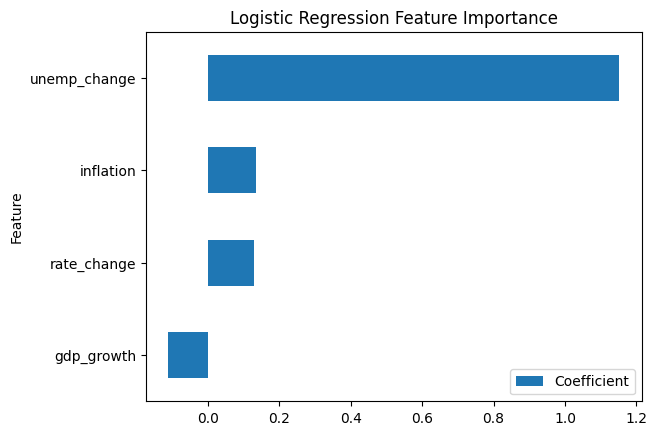

In [42]:
import matplotlib.pyplot as plt

coef_df.sort_values("Coefficient").plot(
    x="Feature",
    y="Coefficient",
    kind="barh"
)

plt.title("Logistic Regression Feature Importance")
plt.show()

In [43]:
# upgrade to random forest for better performance
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.9298245614035088


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.93        57
   macro avg       0.48      0.48      0.48        57
weighted avg       0.93      0.93      0.93        57



In [46]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(
    importance_df.sort_values(
        "Importance",
        ascending=False
    )
)

        Feature  Importance
1     inflation    0.287234
0    gdp_growth    0.275130
3   rate_change    0.272937
2  unemp_change    0.164698


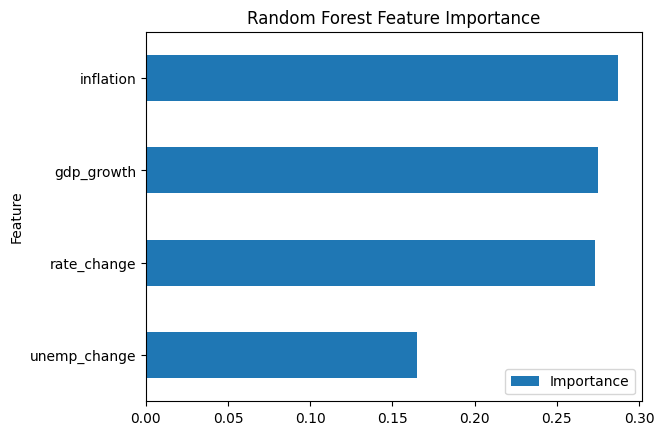

In [47]:
import matplotlib.pyplot as plt

importance_df.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.show()

In [48]:
pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.7/39.2 MB 23.2 MB/s eta 0:00:02
   ------ --------------------------------- 6.3/39.2 MB 14.6 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/39.2 MB 13.9 MB/s eta 0:00:03
   ------------ --------------------------- 12.3/39.2 MB 14.3 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/39.2 MB 16.6 MB/s eta 0:00:02
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.93        57
   macro avg       0.48      0.48      0.48        57
weighted avg       0.93      0.93      0.93        57



In [50]:
print(y.value_counts())

target
0.0    248
1.0     35
Name: count, dtype: int64


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

rf_bal_pred = rf_balanced.predict(X_test)

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_bal_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.95        57
   macro avg       0.48      0.49      0.49        57
weighted avg       0.93      0.95      0.94        57



In [53]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_balanced.feature_importances_
})

print(
    importance_df.sort_values(
        "Importance",
        ascending=False
    )
)

        Feature  Importance
1     inflation    0.275092
0    gdp_growth    0.273178
3   rate_change    0.246175
2  unemp_change    0.205556


In [54]:
print(X.columns)

Index(['gdp_growth', 'inflation', 'unemp_change', 'rate_change'], dtype='str')


In [55]:
print(X.head())

   gdp_growth  inflation  unemp_change  rate_change
1    0.022348  -0.005212          -0.1         0.05
2    0.033370   0.001871          -0.8         0.54
3    0.020478   0.000747          -0.2         0.04
4    0.020613  -0.001120          -0.7         0.25
5    0.015971   0.002242           0.3         0.56


In [56]:
df["gdp_growth_lag1"] = df["gdp_growth"].shift(1)
df["inflation_lag1"] = df["inflation"].shift(1)
df["unemp_change_lag1"] = df["unemp_change"].shift(1)
df["rate_change_lag1"] = df["rate_change"].shift(1)

df = df.dropna()

In [57]:
features = [
    "gdp_growth",
    "inflation",
    "unemp_change",
    "rate_change",
    "gdp_growth_lag1",
    "inflation_lag1",
    "unemp_change_lag1",
    "rate_change_lag1"
]

X = df[features]
y = df["target"]

In [58]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        55
         1.0       0.00      0.00      0.00         2

    accuracy                           0.96        57
   macro avg       0.48      0.50      0.49        57
weighted avg       0.93      0.96      0.95        57



c:\Users\deepa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [61]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(
    importance_df.sort_values(
        "Importance",
        ascending=False
    )
)

             Feature  Importance
5     inflation_lag1    0.207844
0         gdp_growth    0.149396
1          inflation    0.133421
2       unemp_change    0.111588
4    gdp_growth_lag1    0.107662
3        rate_change    0.101314
6  unemp_change_lag1    0.094479
7   rate_change_lag1    0.094296


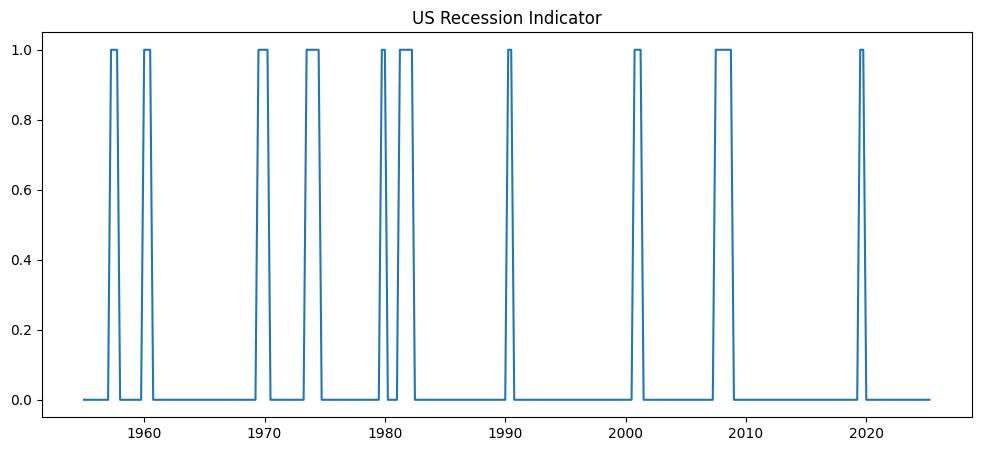

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["DATE"], df["target"])
plt.title("US Recession Indicator")
plt.show()

In [63]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


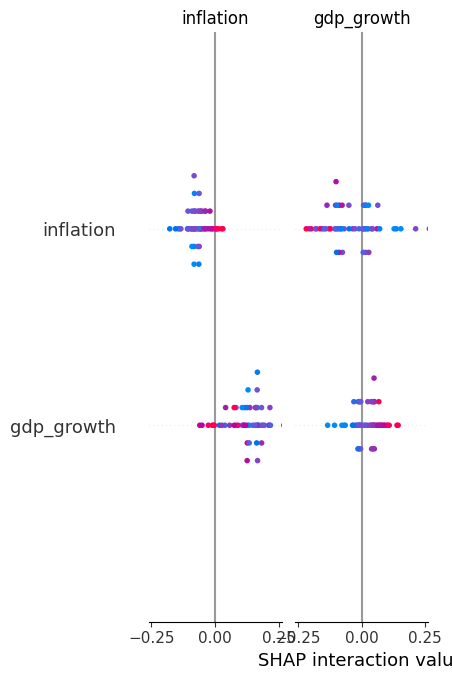

In [64]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [67]:
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

ValueError: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

In [68]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(57, 8, 2)


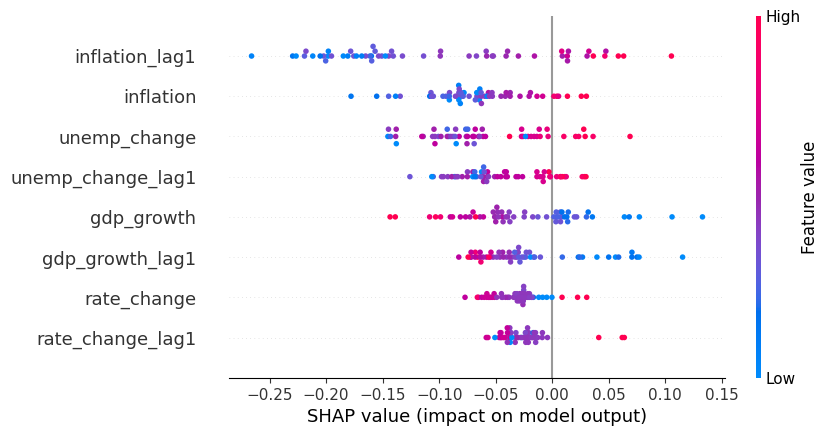

In [69]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
 # Conclusion : Key Findings

# - GDP growth, inflation, unemployment changes, and interest-rate dynamics were used to forecast recession risk.
# - Random Forest achieved high overall accuracy but struggled to identify rare recession events due to class imbalance.
# - SHAP analysis provided interpretability by showing which macroeconomic indicators influenced predictions most strongly.
# - Results demonstrate both the potential and limitations of machine learning for macroeconomic forecasting.

SyntaxError: invalid syntax (188999916.py, line 3)